In [1]:
import os
import numpy as np
import pandas as pd
import mne
from pathlib import Path
import logging
from collections import defaultdict

In [ ]:
# == Configuration ==
# === Logging format: timestamp - level - message ===
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# === Paths ===
CURRENT_DIR = Path.cwd()
PATH_DATA_RAW = CURRENT_DIR / "data" / "raw"

# === Subject lists ===
SUBJECT_IDS = [f'sub-{i}' for i in [
    1117, 1118, 1120, 
    #1124, 1126, 1131, 1132, 1135, 1136,
    #1151, 1160, 1164, 1167, 1169, 1172, 1173, 1178,
    #1182, 1215, 1216, 1219, 1223, 1227, 1233,
    #1234, 1237, 1240, 1243, 1245, 1247, 1250, 1239,
    #1252, 1257, 1261, 1265, 1266, 1268, 1270, 1276, 1281
    ]]

# === BIDS labels ===
BIDS_TASK_LABEL_EEG = '_task-dynamic'
BIDS_EEG_SUFFIX = '_eeg'
BIDS_TASK_LABEL_BEH = '_task-MAT'
BIDS_BEH_SUFFIX = '_behavEEG'

# === ERP parameters ===
ERP_TMIN, ERP_TMAX = -0.5, 2
RESP_PRE, RESP_POST = -1, 0.2
BASELINE_TMIN, BASELINE_TMAX = -0.25, 0


1 visual inspection for bad channels

2 preprocessing: resampling, filtering, rereference, ICA

3 save as BIDS（combine eeg and behvioral data）

In [ ]:
# === Test ===
PATH_PREPROCESS_DATA_BIDS = CURRENT_DIR.parent / '01_Data' / 'preprocess' 
beh_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/beh/*_beh.csv'))
eeg_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/eeg/*.vhdr'))
beh_by_sub = {p.parent.parent.name: p for p in beh_files}
eeg_by_sub = {p.parent.parent.name: p for p in eeg_files}

for sub_id in SUBJECT_IDS:
    path_eeg = eeg_by_sub[f'{sub_id}']
    path_behavior = beh_by_sub[f'{sub_id}']
    logger.info(f"Processing subject: {sub_id}")

    # === Step 1: load eeg and behavior data ===
    data_behavior = pd.read_csv(path_behavior)
    if 'probe_rt' not in data_behavior.columns:
        logger.warning(f"{sub_id}: rt column missing in behavior, skipping")
        continue
    index_valid_trial = data_behavior[data_behavior['rt_is_not_outlier']].index.to_list()

    raw = mne.io.read_raw_brainvision(path_eeg, preload=True, verbose='ERROR')
    events, event_id = mne.events_from_annotations(raw, verbose='ERROR')

    stim_event_id = {"Stimulus/S  8": 8}
    stim_value =8
    stim_events = events[events[:,2]==stim_value]

    assert len(stim_events) == len(data_behavior), f"{sub_id}: events and data_behavior have different lengths"
    print(f'raw length of data:{len(data_behavior)}')

    # === Step 2: Epoch data ===
    epochs_full = mne.Epochs(
        raw,
        events = stim_events,
        event_id = stim_event_id,
        tmin = ERP_TMIN,
        tmax = ERP_TMAX,
        baseline= (BASELINE_TMIN, BASELINE_TMAX),
        reject = {"eeg": 200e-5},
        metadata = data_behavior,
        preload = True,
        event_repeated = 'drop',
        verbose='ERROR',
    )

    beh_clean = epochs_full.metadata.reset_index(drop=True)
    print(f'clean beh data:{len(beh_clean)}; epoch data:{len(epochs_full)}')

# test length
epochs_conditions = len(epochs_full["cue_dimensionality == 4"])
behavior_conditions = len(beh_clean[beh_clean['cue_dimensionality'] == 4])
print(f'epochs_conditions: {epochs_conditions}; behavior_condition: {behavior_conditions}')

2026-06-12 15:06:56,534 - INFO - Processing subject: sub-1117
2026-06-12 15:06:57,414 - INFO - Processing subject: sub-1118


raw length of data:256
clean beh data:256; epoch data:256


2026-06-12 15:06:58,237 - INFO - Processing subject: sub-1120


raw length of data:256
clean beh data:0; epoch data:0
raw length of data:256
clean beh data:40; epoch data:40
epochs_conditions: 7; behavior_condition: 7


2026-06-12 15:29:11,230 - INFO - Processing subject: sub-1117


raw length of data:256


2026-06-12 15:29:12,237 - INFO - Processing subject: sub-1118


raw length of data:256


2026-06-12 15:29:13,204 - INFO - Processing subject: sub-1120


...

raw length of data:256


2026-06-12 15:29:47,623 - INFO - Processing subject: sub-1276


raw length of data:256


2026-06-12 15:29:48,386 - INFO - Processing subject: sub-1281


raw length of data:256
More than 6 channels, truncating title ...
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


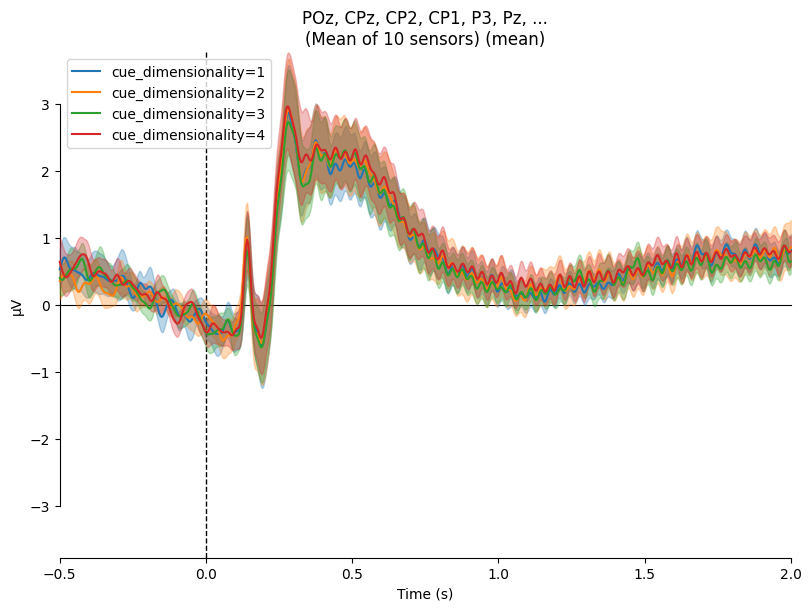

[<Figure size 800x600 with 1 Axes>]

In [ ]:
# Prepare data for plotting
SUBJECT_IDS = [f'sub-{i}' for i in [
    1117, 1118, 1120, 
    1124, 1126, 1131, 1132, 1135, 1136,
    1151, 1160, 1164, 1167, 1169, 1172, 1173, 1178,
    1182, 1215, 1216, 1219, 1223, 1227, 1233,
    1234, 1237, 1240, 1243, 1245, 1247, 1250, 1239,
    1252, 1257, 1261, 1265, 1266, 1268, 1270, 1276, 1281
    ]]
PATH_PREPROCESS_DATA_BIDS = CURRENT_DIR.parent / '01_Data' / 'preprocess' 
PATH_PREPROCESS_DATA_BIDS = Path('/Users/hyijie/Desktop/CPP_local_own/3_Data/preprocessData/CPP_low-level-2_Kosciessa_et_al_2021')
beh_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/beh/*_beh.csv'))
eeg_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/eeg/*.vhdr'))
beh_by_sub = {p.parent.parent.name: p for p in beh_files}
eeg_by_sub = {p.parent.parent.name: p for p in eeg_files}

# save each subject's ERP for each condition
erp_by_conditions = defaultdict(list)

for sub_id in SUBJECT_IDS:
    path_eeg = eeg_by_sub[f'{sub_id}']
    path_behavior = beh_by_sub[f'{sub_id}']
    logger.info(f"Processing subject: {sub_id}")

    # === Step 1: load eeg and behavior data ===
    data_behavior = pd.read_csv(path_behavior)
    if 'probe_rt' not in data_behavior.columns:
        logger.warning(f"{sub_id}: rt column missing in behavior, skipping")
        continue
    index_valid_trial = data_behavior[data_behavior['rt_is_not_outlier']].index.to_list()

    raw = mne.io.read_raw_brainvision(path_eeg, preload=True, verbose='ERROR')
    events, event_id = mne.events_from_annotations(raw, verbose='ERROR')

    stim_event_id = {"Stimulus/S  8": 8}
    stim_value =8
    stim_events = events[events[:,2]==stim_value]

    assert len(stim_events) == len(data_behavior), f"{sub_id}: events and data_behavior have different lengths"
    print(f'raw length of data:{len(data_behavior)}')

    # === Step 2: Epoch data ===
    epochs_full = mne.Epochs(
        raw,
        events = stim_events,
        event_id = stim_event_id,
        tmin = ERP_TMIN,
        tmax = ERP_TMAX,
        baseline= (BASELINE_TMIN, BASELINE_TMAX),
        #reject_by_annotation=True,
        #reject = {"eeg": 200e-5},
        metadata = data_behavior,
        preload = True,
        event_repeated = 'drop',
        verbose='ERROR',
    )

    for con in [1, 2, 3, 4]:
        epochs_condition = epochs_full[f"cue_dimensionality ==  {con}"]
        evoked_condition = epochs_condition.average()#.get_data()
        erp_by_conditions[con].append(evoked_condition)

evokeds_for_plot = {
    f"cue_dimensionality={con}": erp_list
    for con, erp_list in erp_by_conditions.items()
}

CPP_CHANNELS = ["POz", "CPz", "CP2", 'CP1', 'P3', 'Pz', 'P2','PO3','POz','PO4']

mne.viz.plot_compare_evokeds(
    evokeds_for_plot,
    picks=CPP_CHANNELS,
    combine="mean",
    ci=True,
    show=True
)
